# Paper PINNs inverso — Burgers 2D vectorial con flujo rotacional - Juan José Salazar Bedoya - Cristian Camilo Victoria Parra

Este cuaderno reproduce, con componente didáctico, el paper **"Equation identification for fluid flows via physics-informed neural networks"**.

La meta del paper es resolver un **problema inverso**: a partir de pocos datos de una solución de Burgers 2D, estimar los parámetros físicos

$
\phi=(\alpha,\nu),
$

donde \(\alpha\) controla la convección y \(\nu\) controla la difusión.

La ecuación estudiada es

$
\mathbf u_t+\alpha(\mathbf u\cdot\nabla)\mathbf u-\nu\Delta\mathbf u=0,
\qquad \mathbf u=(u,v),
$

en el dominio

$
(x,y,t)\in [0,1]\times[0,1]\times[0,0.499].
$

La estructura sigue el estilo de un notebook didáctico: primero se genera la solución de referencia, luego se construye la PINN, después se entrena y finalmente se producen las tablas y figuras del paper.


## Cómo usar este cuaderno

Ejecuta de arriba hacia abajo.

En Google Colab conviene activar GPU:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**.

Este notebook tiene dos niveles:

1. **Prueba corta**, para verificar que todo funciona.
2. **Réplica del paper**, que usa los tamaños del artículo: malla $256\times256$, 72 tiempos, 10 configuraciones de parámetros y la grilla completa de entrenamientos.

La réplica completa no es un juguete: el paper entrena muchos modelos. Si lo corres completo, espera tiempos largos. La diferencia con versiones tramposas es que aquí las Figuras 2--8 salen de `results_df`, y `results_df` sale de entrenamiento, no de puntos inventados.


## 1. Instalación de dependencias

Usamos:

- `FiPy` para generar la solución de Burgers 2D con volúmenes finitos, como en el paper.
- `PyTorch` para construir la PINN didáctica con derivadas automáticas.
- `NumPy`, `Pandas` y `Matplotlib` para datos, tablas y figuras.

El paper implementa los PINNs con `pinn-jax`, usando `jax`, `flax` y `optax`. Aquí se usa PyTorch para mantener el estilo didáctico del notebook de referencia; la matemática del PINN y de la estimación inversa es la misma.


In [ ]:
# This cell installs fipy and other required libraries.
!pip -q install fipy pyamg pandas matplotlib scipy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 73.6 MB/s eta 0:00:00


## 2. Importaciones y configuración global

Fijamos semillas aleatorias y usamos doble precisión, como en el paper.


In [ ]:
import os
import time
import copy
import math
import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# Doble precisión como en el paper.
torch.set_default_dtype(torch.float64)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| dispositivo:', DEVICE)

# Estilo visual cercano al paper: fondo claro, rejilla suave, marcadores limpios.
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except Exception:
    plt.style.use('default')

CACHE_DIR = Path('/content/pinns_burgers2d_paper_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = CACHE_DIR / 'results_df.csv'


PyTorch: 2.11.0+cu128 | dispositivo: cuda


## 3. Interruptores de ejecución

La variable importante es `RUN_MODE`.

- `"smoke"`: prueba mínima; útil para verificar que el código corre.
- `"demo"`: entrenamiento reducido, figuras generadas desde entrenamiento, pero no equivalente al costo del paper.
- `"paper"`: usa la malla, los tiempos, las configuraciones de datos y los hiperparámetros del paper.

Para una réplica completa, usa:

```python
RUN_MODE = "paper"
RUN_FULL_GRID = True
```

No hay magia: si se quiere repetir el paper, toca pagar el costo computacional del paper.


In [ ]:
# Cambia aquí según lo que quieras ejecutar.
RUN_MODE = "demo"   # "smoke", "demo" o "paper"
RUN_FULL_GRID = True # True para lanzar toda la grilla experimental.

# En modo smoke/demo solo se hacen pocos pasos para comprobar el pipeline.
# En modo paper se activan los tamaños del artículo.


## 4. Parámetros exactos reportados por el paper

El paper usa 10 soluciones de Burgers 2D, variando $\alpha$ y $\nu$. La razón $\alpha/\nu$ actúa como parámetro efectivo relacionado con el número de Reynolds.


In [ ]:
# Tabla 1 del paper: configuraciones de parámetros para generar ground truth.
PARAMETER_GRID = [
    {'nu': 1e-4, 'alpha_values': [1.0, 1.5, 2.0]},
    {'nu': 1e-3, 'alpha_values': [1.0, 1.5, 2.0]},
    {'nu': 1e-2, 'alpha_values': [0.5, 1.0, 1.5, 2.0]},
]

param_rows = []
for row in PARAMETER_GRID:
    for a in row['alpha_values']:
        param_rows.append({'nu': row['nu'], 'alpha': a, 'alpha/nu': a / row['nu']})
params_df = pd.DataFrame(param_rows)
params_df


,nu,alpha,alpha/nu
0,0.0001,1.0,10000.0
1,0.0001,1.5,15000.0
2,0.0001,2.0,20000.0
3,0.0010,1.0,1000.0
4,0.0010,1.5,1500.0
5,0.0010,2.0,2000.0
6,0.0100,0.5,50.0
7,0.0100,1.0,100.0
8,0.0100,1.5,150.0
9,0.0100,2.0,200.0


In [ ]:
# Tabla 3: hiperparámetros del método data-driven del paper.
table3 = pd.DataFrame([
    ['Number of hidden units', 256],
    ['Number of layers', 10],
    ['Activation function', 'tanh'],
    ['Batch size (Data loss)', 2048],
    ['Batch size (IC loss)', 2048],
    ['Batch size (PDE loss)', 8192],
    ['lambda_Data', 1],
    ['lambda_IC', 1],
    ['Optimizer', 'Adam'],
    ['Number of epochs', 50000],
    ['Initial learning rate', '5e-3'],
    ['Minimum learning rate', '1e-6'],
    ['Exponential decay rate', 0.925],
    ['Exponential decay interval', 5000],
], columns=['Hyperparameter', 'Value'])

table3


,Hyperparameter,Value
0,Number of hidden units,256
1,Number of layers,10
2,Activation function,tanh
3,Batch size (Data loss),2048
4,Batch size (IC loss),2048
5,Batch size (PDE loss),8192
6,lambda_Data,1
7,lambda_IC,1
8,Optimizer,Adam
9,Number of epochs,50000


In [ ]:
# Tabla 4: hiperparámetros PINN del paper.
table4 = pd.DataFrame([
    ['Number of hidden units', 256],
    ['Number of layers', 10],
    ['Activation function', 'tanh'],
    ['Batch size (Data loss)', 'Varies'],
    ['Batch size (IC loss)', 1024],
    ['Batch size (PDE loss)', 2048],
    ['lambda_PDE', 1],
    ['lambda_Data', 10],
    ['lambda_IC', 10],
    ['NN Optimizer', 'Adam'],
    ['PDE Optimizer', '{Adam, Newton}'],
    ['Number of gradient steps', 100000],
    ['Parameter estimation interval', '{10 Adam, 100 Newton}'],
    ['Initial NN learning rate', '5e-3'],
    ['Minimum NN learning rate', '1e-5'],
    ['Exponential decay rate', 0.925],
    ['Exponential decay interval', 5000],
    ['PDE parameter step size', '1e-3'],
], columns=['Hyperparameter', 'Value'])

table4


,Hyperparameter,Value
0,Number of hidden units,256
1,Number of layers,10
2,Activation function,tanh
3,Batch size (Data loss),Varies
4,Batch size (IC loss),1024
5,Batch size (PDE loss),2048
6,lambda_PDE,1
7,lambda_Data,10
8,lambda_IC,10
9,NN Optimizer,Adam


## 5. Configuración computacional según el modo

El paper usa:

$
N_x=N_y=256,
\qquad N_t=72,
\qquad t\in[0,0.499].
$

Cada solución tiene

$
256\cdot256\cdot72=4,718,592
$

puntos espacio-temporales.


In [ ]:
@dataclass
class RunConfig:
    # Datos de referencia
    nx: int
    ny: int
    nt: int
    t_final: float
    nonlinear_sweeps: int

    # Arquitectura
    width: int
    depth: int

    # Entrenamiento data-driven
    dd_steps: int
    dd_batch_data: int
    dd_batch_ic: int
    dd_batch_pde: int
    dd_lr0: float
    dd_lr_min: float

    # Entrenamiento PINN
    pinn_steps: int
    pinn_batch_ic: int
    pinn_batch_pde: int
    pinn_lr0: float
    pinn_lr_min: float

    # Evaluación y logging
    eval_points: int
    print_every: int


def get_config(run_mode: str) -> RunConfig:
    if run_mode == 'paper':
        return RunConfig(
            nx=256, ny=256, nt=72, t_final=0.499, nonlinear_sweeps=4,
            width=256, depth=10,
            dd_steps=50000, dd_batch_data=2048, dd_batch_ic=2048, dd_batch_pde=8192,
            dd_lr0=5e-3, dd_lr_min=1e-6,
            pinn_steps=100000, pinn_batch_ic=1024, pinn_batch_pde=2048,
            pinn_lr0=5e-3, pinn_lr_min=1e-5,
            eval_points=200000, print_every=5000,
        )
    if run_mode == 'demo':
        return RunConfig(
            nx=48, ny=48, nt=24, t_final=0.499, nonlinear_sweeps=2,
            width=80, depth=4,
            dd_steps=1500, dd_batch_data=512, dd_batch_ic=256, dd_batch_pde=512,
            dd_lr0=3e-3, dd_lr_min=1e-5,
            pinn_steps=1500, pinn_batch_ic=256, pinn_batch_pde=512,
            pinn_lr0=3e-3, pinn_lr_min=1e-5,
            eval_points=6500, print_every=250,
        )
    if run_mode == 'smoke':
        return RunConfig(
            nx=48, ny=48, nt=16, t_final=0.499, nonlinear_sweeps=1,
            width=48, depth=3,
            dd_steps=80, dd_batch_data=128, dd_batch_ic=128, dd_batch_pde=256,
            dd_lr0=2e-3, dd_lr_min=1e-5,
            pinn_steps=100, pinn_batch_ic=128, pinn_batch_pde=256,
            pinn_lr0=2e-3, pinn_lr_min=1e-5,
            eval_points=5000, print_every=25,
        )
    raise ValueError("RUN_MODE debe ser 'smoke', 'demo' o 'paper'.")

CFG = get_config(RUN_MODE)
CFG


RunConfig(nx=48, ny=48, nt=24, t_final=0.499, nonlinear_sweeps=2, width=80, depth=4, dd_steps=1500, dd_batch_data=512, dd_batch_ic=256, dd_batch_pde=512, dd_lr0=0.003, dd_lr_min=1e-05, pinn_steps=1500, pinn_batch_ic=256, pinn_batch_pde=512, pinn_lr0=0.003, pinn_lr_min=1e-05, eval_points=6500, print_every=250)

## 6. Ecuación de Burgers 2D usada en el paper

La forma vectorial es

$
\mathbf u_t+\alpha(\mathbf u\cdot\nabla)\mathbf u-\nu\Delta\mathbf u=0,
\qquad \mathbf u=(u,v).
$

Es decir,

$
u_t + \alpha(u u_x+v u_y)-\nu(u_{xx}+u_{yy})=0,
$

$
v_t + \alpha(u v_x+v v_y)-\nu(v_{xx}+v_{yy})=0.
$

Las condiciones iniciales son

$
u(x,y,0)=\sin(6\pi y)x(1-x),
$

$
v(x,y,0)=-\sin(6\pi x)y(1-y).
$

Las condiciones de frontera son homogéneas:

$
\mathbf u=0\quad \text{en } \partial([0,1]^2).
$


In [ ]:
def initial_u_np(x, y):
    """u(x,y,0) = sin(6*pi*y)*x*(1-x)."""
    return np.sin(6*np.pi*y) * x * (1.0 - x)


def initial_v_np(x, y):
    """v(x,y,0) = -sin(6*pi*x)*y*(1-y)."""
    return -np.sin(6*np.pi*x) * y * (1.0 - y)


## 7. Generador FiPy de datos de referencia

El paper genera los datos con **FiPy**, usando volúmenes finitos. Esta celda implementa el generador de la solución de referencia.

El término convectivo se resuelve en forma conservativa, y el término difusivo se trata de forma implícita. Para acercarnos al paper usamos `PowerLawConvectionTerm`, que es el tipo de discretización mencionado en el artículo para el término de difusión/convección dentro del esquema de volúmenes finitos.

La salida tiene forma:

```python
U.shape = (nt, ny, nx)
V.shape = (nt, ny, nx)
```

donde `U[k]` y `V[k]` son los campos en el tiempo `t_grid[k]`.


In [ ]:
def _solution_filename(alpha, nu, cfg: RunConfig):
    tag = f"alpha_{alpha:g}_nu_{nu:.0e}_nx_{cfg.nx}_ny_{cfg.ny}_nt_{cfg.nt}_tf_{cfg.t_final}"
    return CACHE_DIR / (tag.replace('.', 'p') + '.npz')


def _cell_values_to_image(phi, nx, ny):
    """Convierte valores de celdas FiPy a imagen [ny, nx] para imshow."""
    arr = np.asarray(phi.value, dtype=np.float64)
    return arr.reshape((nx, ny), order='F').T


def solve_burgers2d_fipy(alpha=2.0, nu=1e-4, cfg: RunConfig = CFG,
                         force=False, verbose=True):
    """
    Genera una solución de referencia para Burgers 2D vectorial usando FiPy.

    Ecuaciones:
        u_t + alpha * div( u * [u, v] ) = nu * Delta u
        v_t + alpha * div( v * [u, v] ) = nu * Delta v

    Esta es la forma conservativa usada para aproximar el término no lineal.
    """
    path = _solution_filename(alpha, nu, cfg)
    if path.exists() and not force:
        data = np.load(path)
        return {
            'x': data['x'], 'y': data['y'], 't': data['t'],
            'U': data['U'], 'V': data['V'],
            'alpha': float(data['alpha']), 'nu': float(data['nu'])
        }

    from fipy import CellVariable, FaceVariable, Grid2D
    from fipy import TransientTerm, DiffusionTerm, PowerLawConvectionTerm

    try:
        # Si pyAMG está disponible, FiPy puede usarlo. Si no, cae al solver por defecto.
        from fipy.solvers.pyAMG import LinearGMRESSolver
        solver = LinearGMRESSolver(tolerance=1e-10, iterations=2000)
    except Exception:
        from fipy import LinearLUSolver
        solver = LinearLUSolver(tolerance=1e-10, iterations=2000)

    nx, ny, nt = cfg.nx, cfg.ny, cfg.nt
    dx = 1.0 / nx
    dy = 1.0 / ny
    dt = cfg.t_final / (nt - 1)

    mesh = Grid2D(dx=dx, dy=dy, nx=nx, ny=ny)
    x_cc, y_cc = mesh.cellCenters
    x_val = np.asarray(x_cc)
    y_val = np.asarray(y_cc)

    u = CellVariable(mesh=mesh, name='u', value=initial_u_np(x_val, y_val), hasOld=True)
    v = CellVariable(mesh=mesh, name='v', value=initial_v_np(x_val, y_val), hasOld=True)

    # Condición de frontera homogénea en todo el borde exterior.
    u.constrain(0.0, where=mesh.exteriorFaces)
    v.constrain(0.0, where=mesh.exteriorFaces)

    velocity = FaceVariable(mesh=mesh, rank=1)

    eq_u = TransientTerm(var=u) + PowerLawConvectionTerm(coeff=velocity, var=u) == DiffusionTerm(coeff=nu, var=u)
    eq_v = TransientTerm(var=v) + PowerLawConvectionTerm(coeff=velocity, var=v) == DiffusionTerm(coeff=nu, var=v)

    x_grid = (np.arange(nx) + 0.5) * dx
    y_grid = (np.arange(ny) + 0.5) * dy
    t_grid = np.linspace(0.0, cfg.t_final, nt)

    U = np.zeros((nt, ny, nx), dtype=np.float64)
    V = np.zeros((nt, ny, nx), dtype=np.float64)
    U[0] = _cell_values_to_image(u, nx, ny)
    V[0] = _cell_values_to_image(v, nx, ny)

    iterator = range(1, nt)
    if verbose:
        iterator = tqdm(iterator, desc=f'FiPy alpha={alpha}, nu={nu:g}')

    for k in iterator:
        u.updateOld()
        v.updateOld()

        for _ in range(cfg.nonlinear_sweeps):
            # Velocidad convectiva de cara: alpha * (u, v).
            velocity[:] = (alpha * u.arithmeticFaceValue, alpha * v.arithmeticFaceValue)
            eq_u.sweep(var=u, dt=dt, solver=solver)
            eq_v.sweep(var=v, dt=dt, solver=solver)

        U[k] = _cell_values_to_image(u, nx, ny)
        V[k] = _cell_values_to_image(v, nx, ny)

    np.savez_compressed(path, x=x_grid, y=y_grid, t=t_grid, U=U, V=V,
                        alpha=np.array(alpha), nu=np.array(nu))
    return {'x': x_grid, 'y': y_grid, 't': t_grid, 'U': U, 'V': V,
            'alpha': alpha, 'nu': nu}

## 8. Figura 1 — snapshots del componente $u$

La Figura 1 del paper muestra $u(x,y,t)$ para

$
\alpha=2,
\qquad \nu=10^{-4},
$

en los tiempos

$
t=0.00,
0.07,
0.14,
0.35.
$


FiPy alpha=2.0, nu=0.0001:   0%|          | 0/23 [00:00<?, ?it/s]

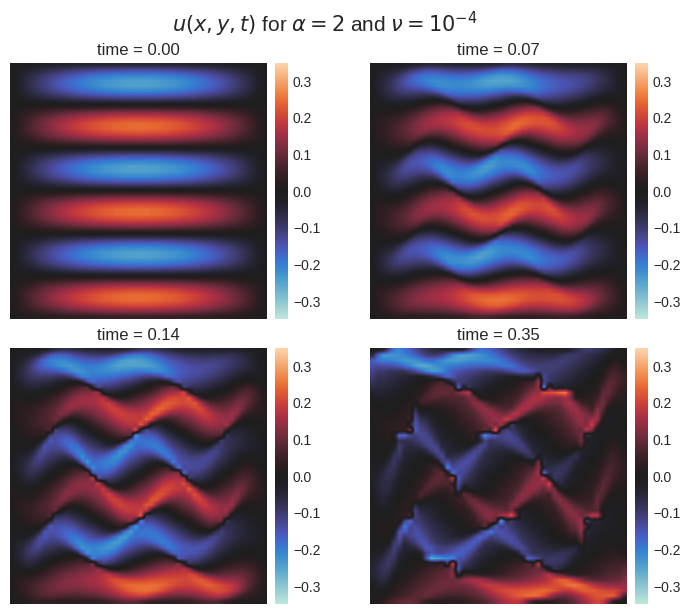

In [ ]:
def nearest_time_index(t_grid, target):
    return int(np.argmin(np.abs(t_grid - target)))


def get_paper_cmap():
    # El paper visualmente se parece al colormap icefire.
    try:
        import seaborn as sns
        return sns.color_palette('icefire', as_cmap=True)
    except Exception:
        return 'RdBu_r'


def plot_figure1(solution, save_path=None):
    x, y, t = solution['x'], solution['y'], solution['t']
    U = solution['U']
    alpha, nu = solution['alpha'], solution['nu']

    times = [0.00, 0.07, 0.14, 0.35]
    idxs = [nearest_time_index(t, tau) for tau in times]

    vmax = 0.35
    vmin = -vmax
    cmap = get_paper_cmap()

    fig, axs = plt.subplots(2, 2, figsize=(7.2, 5.7), constrained_layout=True)
    axs = axs.ravel()

    for ax, tau, idx in zip(axs, times, idxs):
        im = ax.imshow(U[idx], origin='lower', extent=[0, 1, 0, 1],
                       cmap=cmap, vmin=vmin, vmax=vmax, interpolation='bilinear')
        ax.set_title(f'time = {tau:.2f}', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

    fig.suptitle(rf'$u(x,y,t)$ for $\alpha={alpha:g}$ and $\nu=10^{{{int(np.log10(nu))}}}$',
                 fontsize=15, y=1.05)
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


sol_fig1 = solve_burgers2d_fipy(alpha=2.0, nu=1e-4, cfg=CFG, force=False, verbose=True)
plot_figure1(sol_fig1, CACHE_DIR / 'figure1_snapshots.png')


## 9. Muestreo de datos desde la solución de referencia

El paper usa pocos puntos etiquetados en comparación con la solución completa.

Para una solución completa, muestreamos pares

$
(x_n,y_n,t_n)\mapsto (u_n,v_n).
$

También muestreamos puntos de condición inicial y puntos interiores para el residuo de la PDE.


In [ ]:
def sample_solution_points(solution, n_points, rng=None):
    """Muestra puntos etiquetados de la solución completa."""
    if rng is None:
        rng = np.random.default_rng(SEED)

    x, y, t = solution['x'], solution['y'], solution['t']
    U, V = solution['U'], solution['V']
    nt, ny, nx = U.shape
    total = nt * ny * nx
    replace = n_points > total
    idx = rng.choice(total, size=n_points, replace=replace)

    it = idx // (ny * nx)
    rem = idx % (ny * nx)
    iy = rem // nx
    ix = rem % nx

    X = np.stack([x[ix], y[iy], t[it]], axis=1)
    Y = np.stack([U[it, iy, ix], V[it, iy, ix]], axis=1)
    return X.astype(np.float64), Y.astype(np.float64)


def sample_initial_points(n_points, rng=None):
    """Muestra puntos de condición inicial t=0."""
    if rng is None:
        rng = np.random.default_rng(SEED)
    x = rng.random(n_points)
    y = rng.random(n_points)
    t = np.zeros(n_points)
    U0 = initial_u_np(x, y)
    V0 = initial_v_np(x, y)
    X = np.stack([x, y, t], axis=1)
    Y = np.stack([U0, V0], axis=1)
    return X.astype(np.float64), Y.astype(np.float64)


def sample_pde_points(n_points, t_final=0.499, rng=None):
    """Puntos interiores para el residuo físico."""
    if rng is None:
        rng = np.random.default_rng(SEED)
    x = rng.random(n_points)
    y = rng.random(n_points)
    t = t_final * rng.random(n_points)
    X = np.stack([x, y, t], axis=1)
    return X.astype(np.float64)


def to_tensor(a, requires_grad=False):
    z = torch.tensor(a, dtype=torch.float64, device=DEVICE)
    return z.requires_grad_(requires_grad)


## 10. Red neuronal: ED-MLP con frontera dura

El paper usa una arquitectura ED-MLP modificada para satisfacer exactamente las condiciones de frontera homogéneas.

La red cruda produce dos salidas:

$
NN(x,y,t;\theta)=(NN_u,NN_v),
$

pero la solución final se define como

$
\widehat u_\theta=x(1-x)y(1-y)NN_u(x,y,t;\theta),
$

$
\widehat v_\theta=x(1-x)y(1-y)NN_v(x,y,t;\theta).
$

Por eso en $x=0,x=1,y=0,y=1$ la salida es exactamente cero. No se necesita una pérdida de frontera.


In [ ]:
class EDMLP(nn.Module):
    """
    Encoder-Decoder MLP tipo modified MLP.

    Esta versión usa compuertas suaves entre dos codificaciones U y V.
    Mantiene el espíritu de la ED-MLP usada en PINNs modernos y es suficiente
    para reproducir la estructura experimental del paper de forma didáctica.
    """
    def __init__(self, in_dim=3, out_dim=2, width=256, depth=10):
        super().__init__()
        self.U = nn.Linear(in_dim, width)
        self.V = nn.Linear(in_dim, width)
        self.first = nn.Linear(in_dim, width)
        self.hidden = nn.ModuleList([nn.Linear(width, width) for _ in range(depth - 1)])
        self.last = nn.Linear(width, out_dim)
        self.act = nn.Tanh()
        self.reset_parameters()

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, X):
        U = self.act(self.U(X))
        V = self.act(self.V(X))
        H = self.act(self.first(X))
        for layer in self.hidden:
            Z = self.act(layer(H))
            H = (1.0 - Z) * U + Z * V
        return self.last(H)


class HardBoundaryPINN(nn.Module):
    """PINN que satisface u=v=0 en la frontera espacial por construcción."""
    def __init__(self, width=256, depth=10):
        super().__init__()
        self.net = EDMLP(in_dim=3, out_dim=2, width=width, depth=depth)

    def forward(self, X):
        raw = self.net(X)
        x = X[:, 0:1]
        y = X[:, 1:2]
        factor = x * (1.0 - x) * y * (1.0 - y)
        return factor * raw


## 11. Derivadas automáticas y residuo de la PDE

Para el problema inverso necesitamos escribir el residuo separando la parte que depende de los parámetros:

$
r_u=u_t+\alpha A_u-\nu D_u,
$

$
r_v=v_t+\alpha A_v-\nu D_v,
$

con

$
A_u=uu_x+vu_y,
\qquad D_u=u_{xx}+u_{yy},
$

$
A_v=uv_x+vv_y,
\qquad D_v=v_{xx}+v_{yy}.
$

Esto es clave: para pesos $\theta$ fijos, la pérdida PDE es cuadrática en $(\alpha,\nu)$. Por eso una actualización tipo Newton/mínimos cuadrados recupera el mejor parámetro para la red actual.


In [ ]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]


def pde_pieces(model, X):
    """
    Devuelve las piezas del residuo:
        u_t, v_t, A_u, A_v, D_u, D_v.
    """
    X = X.clone().detach().requires_grad_(True)
    pred = model(X)
    u = pred[:, 0:1]
    v = pred[:, 1:2]

    gu = grad(u, X)
    gv = grad(v, X)

    u_x, u_y, u_t = gu[:, 0:1], gu[:, 1:2], gu[:, 2:3]
    v_x, v_y, v_t = gv[:, 0:1], gv[:, 1:2], gv[:, 2:3]

    u_xx = grad(u_x, X)[:, 0:1]
    u_yy = grad(u_y, X)[:, 1:2]
    v_xx = grad(v_x, X)[:, 0:1]
    v_yy = grad(v_y, X)[:, 1:2]

    A_u = u * u_x + v * u_y
    A_v = u * v_x + v * v_y
    D_u = u_xx + u_yy
    D_v = v_xx + v_yy

    return u_t, v_t, A_u, A_v, D_u, D_v


def pde_residual(model, X, alpha, nu):
    u_t, v_t, A_u, A_v, D_u, D_v = pde_pieces(model, X)
    r_u = u_t + alpha * A_u - nu * D_u
    r_v = v_t + alpha * A_v - nu * D_v
    return r_u, r_v


def pde_loss(model, X, alpha, nu):
    r_u, r_v = pde_residual(model, X, alpha, nu)
    return (r_u**2).mean() + (r_v**2).mean()


## 12. Estimación Newton / mínimos cuadrados de $\alpha,\nu$

Con $\theta$ fijo, se resuelve

$
\min_{\alpha,\nu}\left\|b+M
\begin{bmatrix}
\alpha\\
\nu
\end{bmatrix}
\right\|_2^2.
$

Aquí

$
b=\begin{bmatrix}u_t\\v_t\end{bmatrix},
\qquad
M=\begin{bmatrix}A_u&-D_u\\ A_v&-D_v\end{bmatrix}.
$

La solución de mínimos cuadrados equivale a una actualización Newton para esta pérdida cuadrática.


In [ ]:
@torch.no_grad()
def _safe_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu().item())
    return float(x)


def estimate_alpha_nu_least_squares(model, X_pde, ridge=1e-12, clip_nu=True):
    """Estimación cerrada de alpha y nu para red fija."""
    u_t, v_t, A_u, A_v, D_u, D_v = pde_pieces(model, X_pde)

    b = torch.cat([u_t, v_t], dim=0)                    # [2N, 1]
    col_alpha = torch.cat([A_u, A_v], dim=0)            # [2N, 1]
    col_nu = torch.cat([-D_u, -D_v], dim=0)             # [2N, 1]
    M = torch.cat([col_alpha, col_nu], dim=1)           # [2N, 2]

    # Min || b + M phi ||^2 => (M^T M) phi = - M^T b.
    A = M.T @ M + ridge * torch.eye(2, dtype=torch.float64, device=DEVICE)
    rhs = -M.T @ b
    phi = torch.linalg.solve(A, rhs).flatten()

    alpha_hat = phi[0]
    nu_hat = phi[1]
    if clip_nu:
        nu_hat = torch.clamp(nu_hat, min=0.0)

    return alpha_hat.detach(), nu_hat.detach()


## 13. Scheduler de aprendizaje exponencial

El paper usa decaimiento exponencial de la tasa de aprendizaje cada 5000 pasos.


In [ ]:
def paper_lr(step, lr0, lr_min, decay_rate=0.925, decay_interval=5000):
    lr = lr0 * (decay_rate ** (step // decay_interval))
    return max(lr, lr_min)


def set_optimizer_lr(optimizer, lr):
    for group in optimizer.param_groups:
        group['lr'] = lr


## 14. Métricas del paper

La métrica de error relativo de solución es

$
E_{rel}(u,u_\theta;X)
=
\frac{\left(\sum_{x\in X}\|u(x)-u_\theta(x)\|_2^2\right)^{1/2}}
{\left(\sum_{x\in X}\|u(x)\|_2^2\right)^{1/2}}.
$

Para $\alpha$:

$
\frac{|\widehat\alpha-\alpha|}{\alpha}.
$

Para $\nu$, como cambia por órdenes de magnitud, el paper usa error relativo logarítmico:

$
\frac{|\log_{10}(\widehat\nu+\epsilon)-\log_{10}(\nu+\epsilon)|}
{|\log_{10}(\nu+\epsilon)|},
\qquad \epsilon=10^{-8}.
$


In [ ]:
def relative_solution_error(model, solution, n_eval=None, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)
    if n_eval is None:
        n_eval = CFG.eval_points

    X_eval, Y_eval = sample_solution_points(solution, n_eval, rng=rng)
    X_t = to_tensor(X_eval, requires_grad=False)
    Y_true = to_tensor(Y_eval, requires_grad=False)

    model.eval()
    with torch.no_grad():
        Y_pred = model(X_t)
        num = torch.linalg.norm(Y_pred - Y_true)
        den = torch.linalg.norm(Y_true)
    return float((num / den).detach().cpu())


def alpha_error(alpha_hat, alpha_true):
    return abs(float(alpha_hat) - alpha_true) / alpha_true


def nu_log_error(nu_hat, nu_true, eps=1e-8):
    nu_hat = max(float(nu_hat), 0.0)
    return abs(np.log10(nu_hat + eps) - np.log10(nu_true + eps)) / abs(np.log10(nu_true + eps))


## 15. Entrenamiento data-driven — Algoritmo 1 del paper

El baseline data-driven hace dos pasos:

1. Entrena una red solo con datos e IC.
2. Con la red fija, estima $(\alpha,\nu)$ minimizando el residuo PDE.

La física no regulariza el entrenamiento de la red; entra solo al final para estimar los parámetros.


In [ ]:
def train_data_driven(solution, n_data, cfg: RunConfig, seed=SEED):
    rng = np.random.default_rng(seed)
    model = HardBoundaryPINN(width=cfg.width, depth=cfg.depth).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.dd_lr0)

    X_data_all, Y_data_all = sample_solution_points(solution, n_data, rng=rng)
    X_ic_all, Y_ic_all = sample_initial_points(max(cfg.dd_batch_ic, 2048 if RUN_MODE == 'paper' else cfg.dd_batch_ic), rng=rng)

    best_state = copy.deepcopy(model.state_dict())
    best_data_loss = float('inf')
    history = []

    for step in range(1, cfg.dd_steps + 1):
        lr = paper_lr(step, cfg.dd_lr0, cfg.dd_lr_min)
        set_optimizer_lr(optimizer, lr)

        bd = min(cfg.dd_batch_data, len(X_data_all))
        idx_d = rng.choice(len(X_data_all), size=bd, replace=False)
        bi = min(cfg.dd_batch_ic, len(X_ic_all))
        idx_i = rng.choice(len(X_ic_all), size=bi, replace=False)

        Xd = to_tensor(X_data_all[idx_d])
        Yd = to_tensor(Y_data_all[idx_d])
        Xi = to_tensor(X_ic_all[idx_i])
        Yi = to_tensor(Y_ic_all[idx_i])

        pred_d = model(Xd)
        pred_i = model(Xi)
        loss_data = ((pred_d - Yd)**2).mean()
        loss_ic = ((pred_i - Yi)**2).mean()
        loss = loss_data + loss_ic

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if float(loss_data.detach().cpu()) < best_data_loss:
            best_data_loss = float(loss_data.detach().cpu())
            best_state = copy.deepcopy(model.state_dict())

        if step % cfg.print_every == 0 or step == 1:
            history.append({'step': step, 'loss': float(loss.detach().cpu()),
                            'loss_data': float(loss_data.detach().cpu()),
                            'loss_ic': float(loss_ic.detach().cpu()), 'lr': lr})

    model.load_state_dict(best_state)

    Xp = to_tensor(sample_pde_points(cfg.dd_batch_pde, cfg.t_final, rng=rng), requires_grad=True)
    alpha_hat, nu_hat = estimate_alpha_nu_least_squares(model, Xp)

    rel_err = relative_solution_error(model, solution, n_eval=cfg.eval_points, rng=rng)

    row = {
        'method': 'Data-based fitting',
        'pde_optimizer': 'least_squares_after_training',
        'n_data': n_data,
        'alpha_true': solution['alpha'],
        'nu_true': solution['nu'],
        'alpha_hat': float(alpha_hat.cpu()),
        'nu_hat': float(nu_hat.cpu()),
        'alpha_error': alpha_error(float(alpha_hat.cpu()), solution['alpha']),
        'nu_error': nu_log_error(float(nu_hat.cpu()), solution['nu']),
        'relative_error': rel_err,
        'alpha_over_nu': solution['alpha'] / solution['nu'],
    }
    return row, pd.DataFrame(history), model


## 16. Entrenamiento PINN inverso

La PINN minimiza

$
L=L_{PDE}+10L_{Data}+10L_{IC}.
$

Se prueban dos optimizadores para los parámetros PDE:

- `adam`: $\alpha$ y $\nu$ se actualizan con Adam.
- `newton`: los pesos $\theta$ se actualizan con Adam y $(\alpha,\nu)$ se actualizan con mínimos cuadrados cada 100 pasos.


In [ ]:
def train_inverse_pinn(solution, n_data, pde_optimizer='newton', cfg: RunConfig = CFG, seed=SEED):
    rng = np.random.default_rng(seed)
    model = HardBoundaryPINN(width=cfg.width, depth=cfg.depth).to(DEVICE)

    X_data_all, Y_data_all = sample_solution_points(solution, n_data, rng=rng)
    X_ic_all, Y_ic_all = sample_initial_points(max(cfg.pinn_batch_ic, 2048 if RUN_MODE == 'paper' else cfg.pinn_batch_ic), rng=rng)

    # Inicializaciones del paper: alpha ~ U[0,5], nu ~ U[0,0.5].
    alpha_param = nn.Parameter(torch.tensor(rng.uniform(0.0, 5.0), dtype=torch.float64, device=DEVICE))
    nu_param = nn.Parameter(torch.tensor(rng.uniform(0.0, 0.5), dtype=torch.float64, device=DEVICE))

    opt_theta = torch.optim.Adam(model.parameters(), lr=cfg.pinn_lr0)
    if pde_optimizer == 'adam':
        opt_phi = torch.optim.Adam([alpha_param, nu_param], lr=1e-3)
        phi_interval = 10
    elif pde_optimizer == 'newton':
        opt_phi = None
        phi_interval = 100
    else:
        raise ValueError("pde_optimizer debe ser 'adam' o 'newton'.")

    best_state = copy.deepcopy(model.state_dict())
    best_alpha = float(alpha_param.detach().cpu())
    best_nu = float(nu_param.detach().cpu())
    best_loss = float('inf')
    history = []

    for step in range(1, cfg.pinn_steps + 1):
        lr = paper_lr(step, cfg.pinn_lr0, cfg.pinn_lr_min)
        set_optimizer_lr(opt_theta, lr)

        # El paper usa todos los datos disponibles para L_data en PINN.
        Xd = to_tensor(X_data_all)
        Yd = to_tensor(Y_data_all)

        bi = min(cfg.pinn_batch_ic, len(X_ic_all))
        idx_i = rng.choice(len(X_ic_all), size=bi, replace=False)
        Xi = to_tensor(X_ic_all[idx_i])
        Yi = to_tensor(Y_ic_all[idx_i])

        Xp = to_tensor(sample_pde_points(cfg.pinn_batch_pde, cfg.t_final, rng=rng), requires_grad=True)

        loss_pde = pde_loss(model, Xp, alpha_param, nu_param)
        loss_data = ((model(Xd) - Yd)**2).mean()
        loss_ic = ((model(Xi) - Yi)**2).mean()
        loss = loss_pde + 10.0 * loss_data + 10.0 * loss_ic

        opt_theta.zero_grad()
        if opt_phi is not None:
            opt_phi.zero_grad()

        loss.backward()
        opt_theta.step()

        if pde_optimizer == 'adam' and step % phi_interval == 0:
            opt_phi.step()
            with torch.no_grad():
                nu_param.clamp_(min=0.0)

        if pde_optimizer == 'newton' and step % phi_interval == 0:
            Xp_newton = to_tensor(sample_pde_points(cfg.pinn_batch_pde, cfg.t_final, rng=rng), requires_grad=True)
            alpha_hat, nu_hat = estimate_alpha_nu_least_squares(model, Xp_newton)
            with torch.no_grad():
                alpha_param.copy_(alpha_hat)
                nu_param.copy_(torch.clamp(nu_hat, min=0.0))

        current_loss = float(loss.detach().cpu())
        if current_loss < best_loss:
            best_loss = current_loss
            best_state = copy.deepcopy(model.state_dict())
            best_alpha = float(alpha_param.detach().cpu())
            best_nu = float(nu_param.detach().cpu())

        if step % cfg.print_every == 0 or step == 1:
            history.append({
                'step': step,
                'loss': current_loss,
                'loss_pde': float(loss_pde.detach().cpu()),
                'loss_data': float(loss_data.detach().cpu()),
                'loss_ic': float(loss_ic.detach().cpu()),
                'alpha_hat': float(alpha_param.detach().cpu()),
                'nu_hat': float(nu_param.detach().cpu()),
                'lr': lr,
            })

    model.load_state_dict(best_state)
    rel_err = relative_solution_error(model, solution, n_eval=cfg.eval_points, rng=rng)

    row = {
        'method': 'PINN',
        'pde_optimizer': pde_optimizer,
        'n_data': n_data,
        'alpha_true': solution['alpha'],
        'nu_true': solution['nu'],
        'alpha_hat': best_alpha,
        'nu_hat': best_nu,
        'alpha_error': alpha_error(best_alpha, solution['alpha']),
        'nu_error': nu_log_error(best_nu, solution['nu']),
        'relative_error': rel_err,
        'alpha_over_nu': solution['alpha'] / solution['nu'],
    }
    return row, pd.DataFrame(history), model


## 17. Prueba individual del pipeline

Antes de lanzar toda la grilla, hacemos una corrida individual. En `RUN_MODE="smoke"` no busca reproducir los valores del paper; solo verifica que todos los componentes conectan bien.


In [ ]:
# Corrida de prueba: una configuración pequeña.
smoke_alpha = 2.0
smoke_nu = 1e-4
smoke_n_data = 2048 if RUN_MODE == 'paper' else 256

sol_test = solve_burgers2d_fipy(alpha=smoke_alpha, nu=smoke_nu, cfg=CFG, force=False, verbose=True)
row_test, hist_test, model_test = train_inverse_pinn(
    sol_test, n_data=smoke_n_data, pde_optimizer='newton', cfg=CFG, seed=SEED
)

print(row_test)
hist_test.tail()


{'method': 'PINN', 'pde_optimizer': 'newton', 'n_data': 256, 'alpha_true': 2.0, 'nu_true': 0.0001, 'alpha_hat': 1.1371744210622161, 'nu_hat': 0.028541280933851703, 'alpha_error': 0.43141278946889194, 'nu_error': np.float64(0.6138642109269637), 'relative_error': 0.7798436746354874, 'alpha_over_nu': 20000.0}


,step,loss,loss_pde,loss_data,loss_ic,alpha_hat,nu_hat,lr
2,500,0.174118,0.008418,0.008468,0.008102,14.520053,0.043169,0.003
3,750,0.156644,0.004685,0.008079,0.007117,11.365579,0.039912,0.003
4,1000,0.152049,0.011887,0.007778,0.006238,8.994521,0.035232,0.003
5,1250,0.124505,0.014425,0.007334,0.003673,3.332179,0.034629,0.003
6,1500,0.074376,0.008420,0.006110,0.000486,0.857820,0.026623,0.003


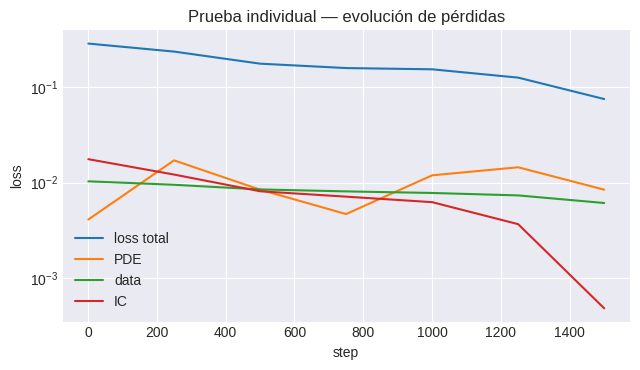

In [ ]:
# Curva de entrenamiento de la prueba.
plt.figure(figsize=(6.5, 3.8))
plt.semilogy(hist_test['step'], hist_test['loss'], label='loss total')
plt.semilogy(hist_test['step'], hist_test['loss_pde'], label='PDE')
plt.semilogy(hist_test['step'], hist_test['loss_data'], label='data')
plt.semilogy(hist_test['step'], hist_test['loss_ic'], label='IC')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Prueba individual — evolución de pérdidas')
plt.legend()
plt.tight_layout()
plt.show()


## 18. Grilla experimental completa

El paper entrena:

### PINNs

- Datos: 2048, 8192, 32768.
- Optimizadores PDE: Adam y Newton.
- 10 configuraciones de $(\alpha,\nu)$.

Total: $3\cdot2\cdot10=60$ entrenamientos PINN.

### Baseline data-driven

- Datos: 128, 512, 2048, 8192, 32768, 131072.
- 10 configuraciones de $(\alpha,\nu)$.

Total: $6\cdot10=60$ entrenamientos data-driven.

En total son 120 entrenamientos. Por eso esta celda está protegida por `RUN_FULL_GRID`.


In [ ]:
def parameter_pairs_for_run(run_mode):
    if run_mode == 'smoke':
        return [(2.0, 1e-4)]
    return [(row['alpha'], row['nu']) for _, row in params_df.iterrows()]


def data_sizes_for_run(run_mode):
    if run_mode == 'paper':
        pinn_sizes = [2048, 8192, 32768]
        dd_sizes = [128, 512, 2048, 8192, 32768, 131072]
    elif run_mode == 'demo':
        pinn_sizes = [512, 2048]
        dd_sizes = [128, 512, 2048]
    else:
        pinn_sizes = [256]
        dd_sizes = [128]
    return pinn_sizes, dd_sizes


def append_result(row, path=RESULTS_PATH):
    df_row = pd.DataFrame([row])
    if path.exists():
        old = pd.read_csv(path)
        new = pd.concat([old, df_row], ignore_index=True)
    else:
        new = df_row
    new.to_csv(path, index=False)


def run_full_experiment(cfg: RunConfig, run_mode=RUN_MODE):
    pinn_sizes, dd_sizes = data_sizes_for_run(run_mode)
    param_pairs = parameter_pairs_for_run(run_mode)

    all_rows = []
    for alpha, nu in param_pairs:
        solution = solve_burgers2d_fipy(alpha=alpha, nu=nu, cfg=cfg, force=False, verbose=True)

        for n_data in dd_sizes:
            print(f'\n[Data-driven] alpha={alpha}, nu={nu:g}, n_data={n_data}')
            row, hist, _ = train_data_driven(solution, n_data=n_data, cfg=cfg,
                                             seed=SEED + int(n_data) + int(1000*alpha))
            append_result(row)
            all_rows.append(row)

        for n_data in pinn_sizes:
            for opt_name in ['newton', 'adam']:
                print(f'\n[PINN] alpha={alpha}, nu={nu:g}, n_data={n_data}, opt={opt_name}')
                row, hist, _ = train_inverse_pinn(solution, n_data=n_data,
                                                  pde_optimizer=opt_name, cfg=cfg,
                                                  seed=SEED + int(n_data) + int(1000*alpha))
                append_result(row)
                all_rows.append(row)

    return pd.DataFrame(all_rows)


if RUN_FULL_GRID:
    if RESULTS_PATH.exists():
        print('Ya existe results_df.csv. Se añadirán nuevas filas si corres de nuevo.')
    results_df = run_full_experiment(CFG, RUN_MODE)
else:
    print('RUN_FULL_GRID=False: no se lanza la grilla completa.')
    print('Para generar Figuras 2--8 desde entrenamiento completo, pon RUN_FULL_GRID=True y vuelve a ejecutar esta celda.')


FiPy alpha=1.0, nu=0.0001:   0%|          | 0/23 [00:00<?, ?it/s]


[Data-driven] alpha=1.0, nu=0.0001, n_data=128

[Data-driven] alpha=1.0, nu=0.0001, n_data=512

[Data-driven] alpha=1.0, nu=0.0001, n_data=2048

[PINN] alpha=1.0, nu=0.0001, n_data=512, opt=newton

[PINN] alpha=1.0, nu=0.0001, n_data=512, opt=adam

[PINN] alpha=1.0, nu=0.0001, n_data=2048, opt=newton

[PINN] alpha=1.0, nu=0.0001, n_data=2048, opt=adam


FiPy alpha=1.5, nu=0.0001:   0%|          | 0/23 [00:00<?, ?it/s]


[Data-driven] alpha=1.5, nu=0.0001, n_data=128

[Data-driven] alpha=1.5, nu=0.0001, n_data=512

[Data-driven] alpha=1.5, nu=0.0001, n_data=2048

[PINN] alpha=1.5, nu=0.0001, n_data=512, opt=newton

[PINN] alpha=1.5, nu=0.0001, n_data=512, opt=adam

[PINN] alpha=1.5, nu=0.0001, n_data=2048, opt=newton

[PINN] alpha=1.5, nu=0.0001, n_data=2048, opt=adam

[Data-driven] alpha=2.0, nu=0.0001, n_data=128

[Data-driven] alpha=2.0, nu=0.0001, n_data=512

[Data-driven] alpha=2.0, nu=0.0001, n_data=2048

[PINN] alpha=2.0, nu=0.0001, n_data=512, opt=newton

[PINN] alpha=2.0, nu=0.0001, n_data=512, opt=adam

[PINN] alpha=2.0, nu=0.0001, n_data=2048, opt=newton

[PINN] alpha=2.0, nu=0.0001, n_data=2048, opt=adam


FiPy alpha=1.0, nu=0.001:   0%|          | 0/23 [00:00<?, ?it/s]

...


[Data-driven] alpha=1.0, nu=0.01, n_data=128

[Data-driven] alpha=1.0, nu=0.01, n_data=512

[Data-driven] alpha=1.0, nu=0.01, n_data=2048

[PINN] alpha=1.0, nu=0.01, n_data=512, opt=newton

[PINN] alpha=1.0, nu=0.01, n_data=512, opt=adam

[PINN] alpha=1.0, nu=0.01, n_data=2048, opt=newton

[PINN] alpha=1.0, nu=0.01, n_data=2048, opt=adam


FiPy alpha=1.5, nu=0.01:   0%|          | 0/23 [00:00<?, ?it/s]


[Data-driven] alpha=1.5, nu=0.01, n_data=128

[Data-driven] alpha=1.5, nu=0.01, n_data=512

[Data-driven] alpha=1.5, nu=0.01, n_data=2048

[PINN] alpha=1.5, nu=0.01, n_data=512, opt=newton

[PINN] alpha=1.5, nu=0.01, n_data=512, opt=adam

[PINN] alpha=1.5, nu=0.01, n_data=2048, opt=newton

[PINN] alpha=1.5, nu=0.01, n_data=2048, opt=adam


FiPy alpha=2.0, nu=0.01:   0%|          | 0/23 [00:00<?, ?it/s]


[Data-driven] alpha=2.0, nu=0.01, n_data=128

[Data-driven] alpha=2.0, nu=0.01, n_data=512

[Data-driven] alpha=2.0, nu=0.01, n_data=2048

[PINN] alpha=2.0, nu=0.01, n_data=512, opt=newton

[PINN] alpha=2.0, nu=0.01, n_data=512, opt=adam

[PINN] alpha=2.0, nu=0.01, n_data=2048, opt=newton

[PINN] alpha=2.0, nu=0.01, n_data=2048, opt=adam


## 19. Cargar resultados entrenados

Las figuras del paper deben salir de `results_df`. Si no existe `results_df.csv`, no se dibujan figuras inventadas.


In [ ]:
if RESULTS_PATH.exists():
    results_df = pd.read_csv(RESULTS_PATH)
else:
    print('No existe results_df.csv todavía. Usaré solo la corrida individual como muestra didáctica.')
    print('Para las Figuras 2--8 reales, ejecuta la grilla completa.')
    results_df = pd.DataFrame([row_test])

results_df.head(), results_df.shape


(               method                 pde_optimizer  n_data  alpha_true  \
 0  Data-based fitting  least_squares_after_training     128         1.0   
 1  Data-based fitting  least_squares_after_training     512         1.0   
 2  Data-based fitting  least_squares_after_training    2048         1.0   
 3                PINN                        newton     512         1.0   
 4                PINN                          adam     512         1.0   
 
    nu_true  alpha_hat    nu_hat  alpha_error  nu_error  relative_error  \
 0   0.0001   0.339661  0.001096     0.660339  0.259955        0.958478   
 1   0.0001   0.330283  0.000294     0.669717  0.117157        0.365334   
 2   0.0001   0.473226  0.000442     0.526774  0.161381        0.234919   
 3   0.0001   0.469309  0.001794     0.530691  0.313477        0.279854   
 4   0.0001   0.167303  0.000028     0.832697  0.136662        0.361657   
 
    alpha_over_nu  
 0        10000.0  
 1        10000.0  
 2        10000.0  
 3        

## 20. Funciones de estilo para replicar Figuras 2--8

Los gráficos usan:

- eje $x$: $\alpha/\nu$, en escala logarítmica;
- eje $y$: error, en escala logarítmica;
- color: valor de $\alpha$;
- marcador: valor de $\nu$;
- línea negra punteada: umbral de éxito del 10%.


In [ ]:
ALPHA_COLORS = {
    0.5: '#1f77b4',
    1.0: '#ff7f0e',
    1.5: '#2ca02c',
    2.0: '#d62728',
}

NU_MARKERS = {
    1e-4: 'o',
    1e-3: 'x',
    1e-2: 's',
}


def _scatter_error(ax, df, y_col, title=None):
    for _, row in df.iterrows():
        alpha = float(row['alpha_true'])
        nu = float(row['nu_true'])
        ax.scatter(row['alpha_over_nu'], row[y_col],
                   color=ALPHA_COLORS.get(alpha, 'black'),
                   marker=NU_MARKERS.get(nu, 'o'),
                   s=55, linewidths=1.8)
    ax.axhline(0.1, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\alpha/\nu$')
    if title:
        ax.set_title(title, fontsize=10)


def add_alpha_nu_legend(fig, anchor=(1.02, 0.5)):
    alpha_handles = [Line2D([0], [0], marker='o', linestyle='None', color=c,
                            label=f'{a:g}', markersize=7) for a, c in ALPHA_COLORS.items()]
    nu_handles = [Line2D([0], [0], marker=m, linestyle='None', color='black',
                         label=f'{nu:g}', markersize=7) for nu, m in NU_MARKERS.items()]
    handles = [Line2D([], [], linestyle='None', label=r'$\alpha$')] + alpha_handles + \
              [Line2D([], [], linestyle='None', label=r'$\nu$')] + nu_handles
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=anchor, frameon=True)


## 21. Figura 2 — comparación PINN Newton vs data-driven

La Figura 2 compara, para 2048, 8192 y 32768 datos:

- error en $\alpha$,
- error en $\nu$,
- error relativo de solución.


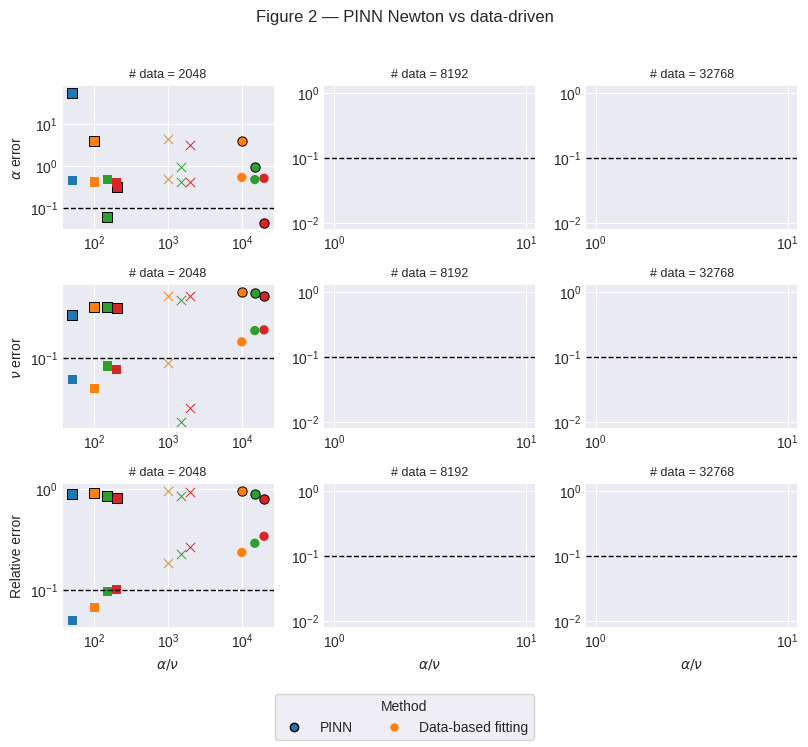

In [ ]:
def plot_figure2(results_df, save_path=None):
    ncols = [2048, 8192, 32768]
    y_rows = [('alpha_error', r'$\alpha$ error'),
              ('nu_error', r'$\nu$ error'),
              ('relative_error', 'Relative error')]

    fig, axs = plt.subplots(3, 3, figsize=(8.2, 7.2), sharex=False)

    for i, (y_col, y_label) in enumerate(y_rows):
        for j, n in enumerate(ncols):
            ax = axs[i, j]
            d = results_df[
                (results_df['n_data'] == n) &
                (
                    ((results_df['method'] == 'PINN') & (results_df['pde_optimizer'] == 'newton')) |
                    (results_df['method'] == 'Data-based fitting')
                )
            ]
            for method, marker_edge in [('PINN', 'black'), ('Data-based fitting', 'none')]:
                dm = d[d['method'] == method]
                for _, row in dm.iterrows():
                    alpha = float(row['alpha_true'])
                    nu = float(row['nu_true'])
                    ax.scatter(row['alpha_over_nu'], row[y_col],
                               color=ALPHA_COLORS.get(alpha, 'black'),
                               marker=NU_MARKERS.get(nu, 'o'), s=45,
                               edgecolors=marker_edge, linewidths=0.7)
            ax.axhline(0.1, color='black', linestyle='--', linewidth=1)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_title(f'# data = {n}', fontsize=9)
            if j == 0:
                ax.set_ylabel(y_label)
            if i == 2:
                ax.set_xlabel(r'$\alpha/\nu$')

    method_handles = [
        Line2D([0], [0], marker='o', linestyle='None', color='tab:blue', markeredgecolor='black', label='PINN'),
        Line2D([0], [0], marker='o', linestyle='None', color='tab:orange', markeredgecolor='none', label='Data-based fitting')
    ]
    fig.legend(handles=method_handles, title='Method', loc='lower center', ncol=2, frameon=True)
    fig.suptitle('Figure 2 — PINN Newton vs data-driven', y=1.02)
    fig.tight_layout(rect=[0, 0.08, 1, 1])
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_figure2(results_df, CACHE_DIR / 'figure2.png')


## 22. Figura 3 — data-driven con 8192, 32768 y 131072 datos


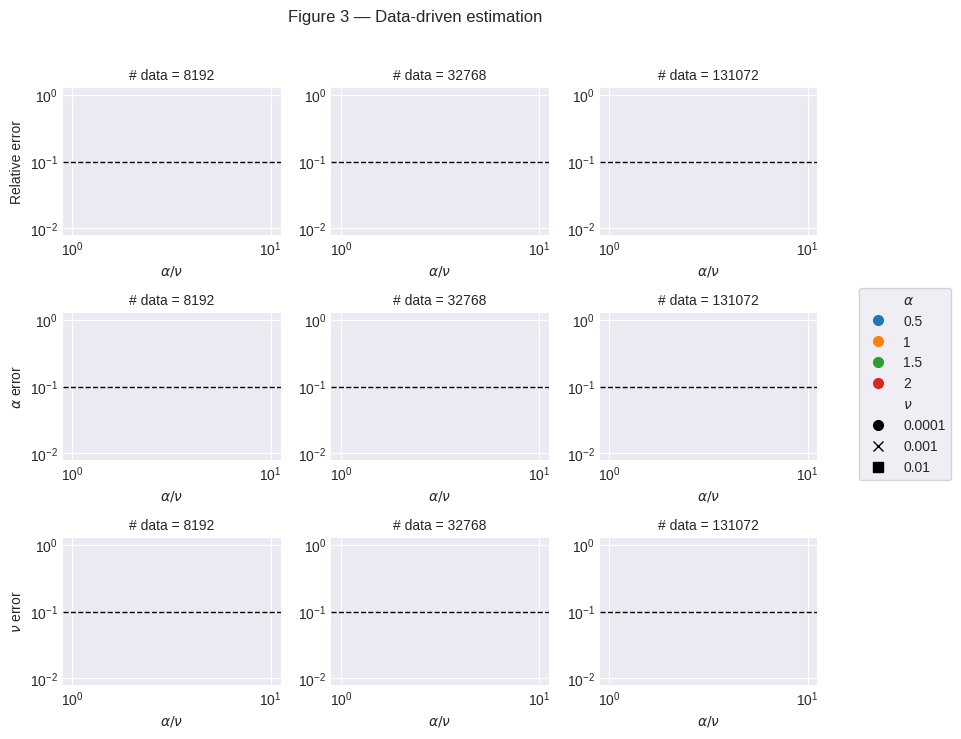

In [ ]:
def plot_figure3(results_df, save_path=None):
    ncols = [8192, 32768, 131072]
    y_rows = [('relative_error', 'Relative error'),
              ('alpha_error', r'$\alpha$ error'),
              ('nu_error', r'$\nu$ error')]

    dbase = results_df[results_df['method'] == 'Data-based fitting']
    fig, axs = plt.subplots(3, 3, figsize=(8.4, 7.2))
    for i, (y_col, y_label) in enumerate(y_rows):
        for j, n in enumerate(ncols):
            ax = axs[i, j]
            d = dbase[dbase['n_data'] == n]
            _scatter_error(ax, d, y_col, title=f'# data = {n}')
            if j == 0:
                ax.set_ylabel(y_label)
    add_alpha_nu_legend(fig, anchor=(1.02, 0.5))
    fig.suptitle('Figure 3 — Data-driven estimation', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_figure3(results_df, CACHE_DIR / 'figure3.png')


## 23. Figura 4 — errores de parámetros para PINNs


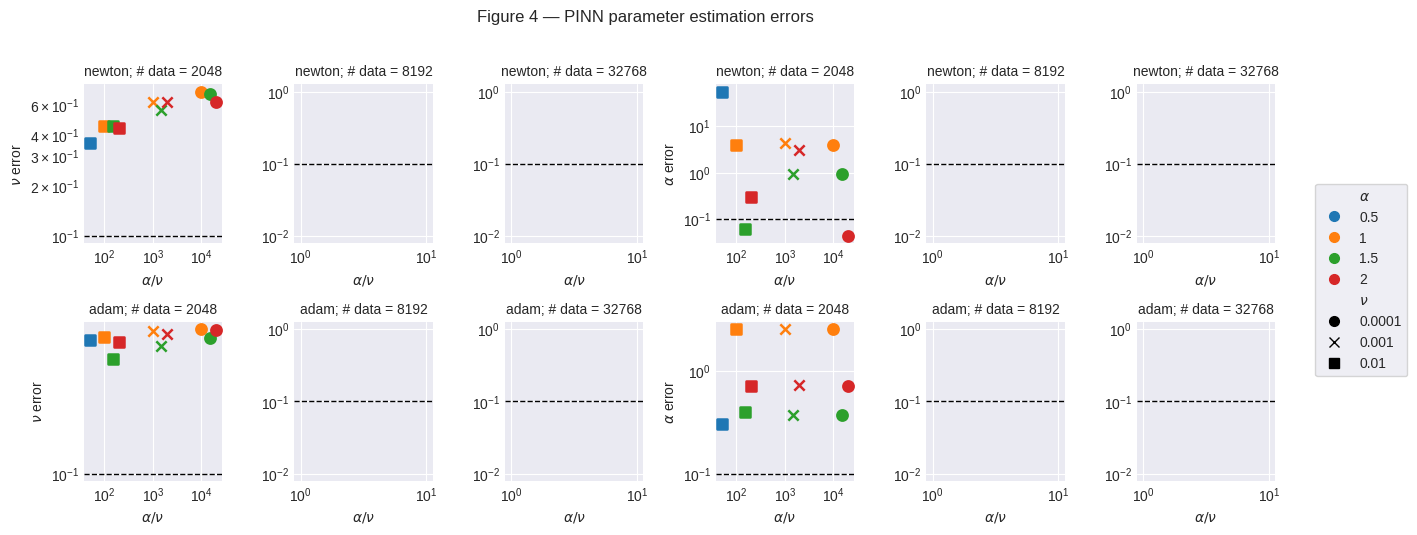

In [ ]:
def plot_figure4(results_df, save_path=None):
    dbase = results_df[results_df['method'] == 'PINN']
    optimizers = ['newton', 'adam']
    ncols = [2048, 8192, 32768]
    y_groups = [('nu_error', r'$\nu$ error'), ('alpha_error', r'$\alpha$ error')]

    fig, axs = plt.subplots(2, 6, figsize=(13.0, 5.2), sharex=False)
    for row_i, opt in enumerate(optimizers):
        for block_i, (y_col, y_label) in enumerate(y_groups):
            for j, n in enumerate(ncols):
                ax = axs[row_i, block_i*3 + j]
                d = dbase[(dbase['pde_optimizer'] == opt) & (dbase['n_data'] == n)]
                _scatter_error(ax, d, y_col, title=f'{opt}; # data = {n}')
                if block_i == 0 and j == 0:
                    ax.set_ylabel(y_label)
                if block_i == 1 and j == 0:
                    ax.set_ylabel(y_label)
    add_alpha_nu_legend(fig, anchor=(1.01, 0.5))
    fig.suptitle('Figure 4 — PINN parameter estimation errors', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_figure4(results_df, CACHE_DIR / 'figure4.png')


## 24. Figura 5 — error relativo de solución para PINNs


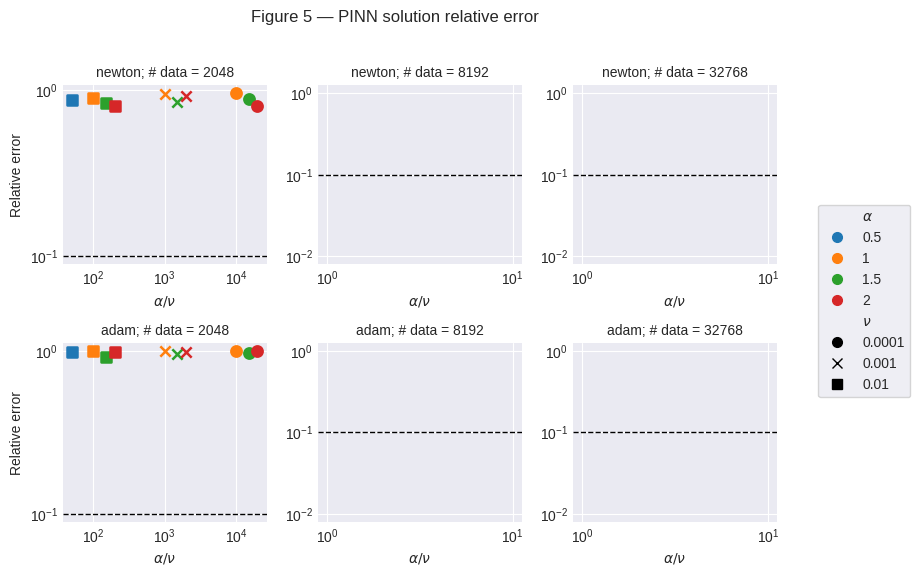

In [ ]:
def plot_figure5(results_df, save_path=None):
    dbase = results_df[results_df['method'] == 'PINN']
    optimizers = ['newton', 'adam']
    ncols = [2048, 8192, 32768]

    fig, axs = plt.subplots(2, 3, figsize=(8.0, 5.6))
    for i, opt in enumerate(optimizers):
        for j, n in enumerate(ncols):
            ax = axs[i, j]
            d = dbase[(dbase['pde_optimizer'] == opt) & (dbase['n_data'] == n)]
            _scatter_error(ax, d, 'relative_error', title=f'{opt}; # data = {n}')
            if j == 0:
                ax.set_ylabel('Relative error')
    add_alpha_nu_legend(fig, anchor=(1.02, 0.5))
    fig.suptitle('Figure 5 — PINN solution relative error', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_figure5(results_df, CACHE_DIR / 'figure5.png')


## 25. Figuras 6, 7 y 8 — baseline data-driven completo

Estas tres figuras separan los errores del baseline data-driven:

- Figura 6: error relativo de solución.
- Figura 7: error en $\alpha$.
- Figura 8: error en $\nu$.


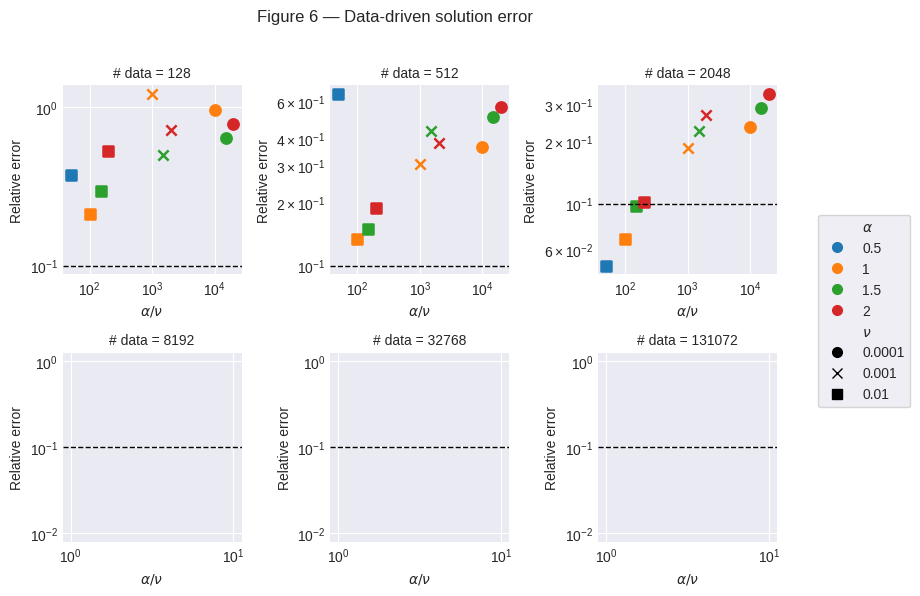

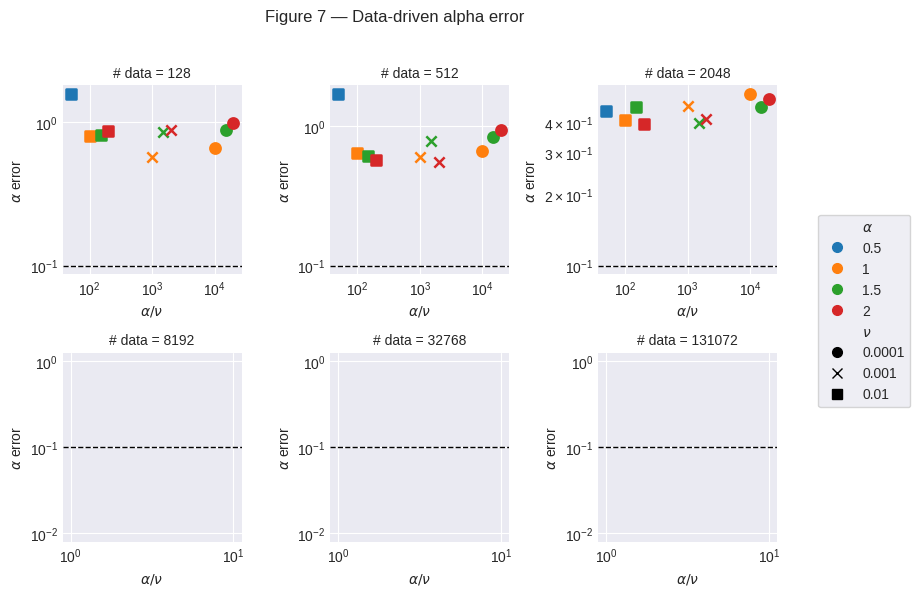

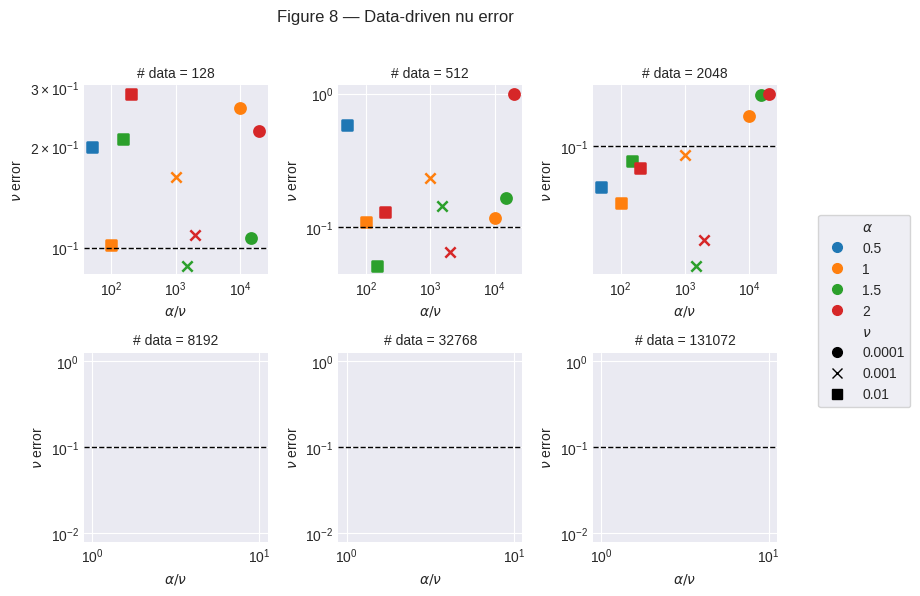

In [ ]:
def plot_data_driven_grid(results_df, y_col, ylabel, title, save_path=None):
    dbase = results_df[results_df['method'] == 'Data-based fitting']
    ncols = [128, 512, 2048, 8192, 32768, 131072]
    fig, axs = plt.subplots(2, 3, figsize=(8.0, 5.8))
    axs = axs.ravel()
    for ax, n in zip(axs, ncols):
        d = dbase[dbase['n_data'] == n]
        _scatter_error(ax, d, y_col, title=f'# data = {n}')
        ax.set_ylabel(ylabel)
    add_alpha_nu_legend(fig, anchor=(1.02, 0.5))
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_data_driven_grid(results_df, 'relative_error', 'Relative error',
                      'Figure 6 — Data-driven solution error', CACHE_DIR / 'figure6.png')
plot_data_driven_grid(results_df, 'alpha_error', r'$\alpha$ error',
                      'Figure 7 — Data-driven alpha error', CACHE_DIR / 'figure7.png')
plot_data_driven_grid(results_df, 'nu_error', r'$\nu$ error',
                      'Figure 8 — Data-driven nu error', CACHE_DIR / 'figure8.png')


## 26. Tabla 2 — promedios entrenados

La Tabla 2 del paper promedia sobre el espacio de parámetros y compara Adam vs Newton para PINNs.

Aquí la tabla se calcula directamente desde `results_df`.


In [ ]:
def make_table2_from_results(results_df):
    d = results_df[results_df['method'] == 'PINN'].copy()
    if d.empty:
        return pd.DataFrame(columns=['PDE optimizer', '# data', 'alpha error', 'Relative error', 'nu error'])
    tab = (
        d.groupby(['pde_optimizer', 'n_data'], as_index=False)
         .agg({'alpha_error': 'mean', 'relative_error': 'mean', 'nu_error': 'mean'})
         .rename(columns={
             'pde_optimizer': 'PDE optimizer',
             'n_data': '# data',
             'alpha_error': 'alpha error',
             'relative_error': 'Relative error',
             'nu_error': 'nu error'
         })
    )
    order = {'adam': 0, 'newton': 1}
    tab['_order'] = tab['PDE optimizer'].map(order)
    tab = tab.sort_values(['# data', '_order']).drop(columns='_order')
    return tab

table2_reproduced = make_table2_from_results(results_df)
table2_reproduced


,PDE optimizer,# data,alpha error,Relative error,nu error
0,adam,512,1.060146,0.384525,0.337898
2,newton,512,0.813796,0.548233,0.342569
1,adam,2048,1.134802,0.979736,0.767024
3,newton,2048,7.300168,0.875054,0.552538


In [ ]:
# Tabla 2 publicada en el paper, para comparar cuando ejecutes la grilla completa.
table2_published = pd.DataFrame([
    ['Adam', 2048, 0.080, 0.152, 0.093],
    ['Newton', 2048, 0.086, 0.150, 0.056],
    ['Adam', 8192, 0.085, 0.139, 0.097],
    ['Newton', 8192, 0.085, 0.130, 0.065],
    ['Adam', 32768, 0.067, 0.139, 0.101],
    ['Newton', 32768, 0.088, 0.126, 0.071],
], columns=['PDE optimizer', '# data', 'alpha error', 'Relative error', 'nu error'])

table2_published


,PDE optimizer,# data,alpha error,Relative error,nu error
0,Adam,2048,0.080,0.152,0.093
1,Newton,2048,0.086,0.150,0.056
2,Adam,8192,0.085,0.139,0.097
3,Newton,8192,0.085,0.130,0.065
4,Adam,32768,0.067,0.139,0.101
5,Newton,32768,0.088,0.126,0.071


## 27. Comparación automática contra la Tabla 2 publicada

Cuando `results_df` contiene la grilla completa del paper, esta celda muestra la diferencia entre tu reproducción y la tabla publicada.

Diferencias pequeñas son normales por:

- inicialización aleatoria,
- versión de librerías,
- hardware,
- detalles internos del solver FiPy,
- ausencia de checkpoints originales del paper.

Lo que no hacemos aquí es inventar una tabla para que se vea bonita. Si no entrenaste, no hay réplica numérica.


In [ ]:
def compare_table2(reproduced, published):
    if reproduced.empty:
        print('No hay resultados PINN entrenados suficientes todavía.')
        return None
    r = reproduced.copy()
    p = published.copy()
    r['PDE optimizer'] = r['PDE optimizer'].str.capitalize()
    merged = p.merge(r, on=['PDE optimizer', '# data'], suffixes=('_paper', '_run'))
    for col in ['alpha error', 'Relative error', 'nu error']:
        merged[col + ' diff'] = merged[col + '_run'] - merged[col + '_paper']
    return merged

comparison_table2 = compare_table2(table2_reproduced, table2_published)
comparison_table2


,PDE optimizer,# data,alpha error_paper,Relative error_paper,nu error_paper,alpha error_run,Relative error_run,nu error_run,alpha error diff,Relative error diff,nu error diff
0,Adam,2048,0.080,0.152,0.093,1.134802,0.979736,0.767024,1.054802,0.827736,0.674024
1,Newton,2048,0.086,0.150,0.056,7.300168,0.875054,0.552538,7.214168,0.725054,0.496538


## 28. Guardar figuras y resultados

Al terminar la grilla, este bloque deja todo en una carpeta comprimida.


In [ ]:
# Guardado compacto para descargar resultados desde Colab.
if RESULTS_PATH.exists():
    print('Resultados guardados en:', RESULTS_PATH)
else:
    print('Todavía no existe archivo de resultados completo.')

print('Carpeta cache:', CACHE_DIR)


Resultados guardados en: /content/pinns_burgers2d_paper_cache/results_df.csv
Carpeta cache: /content/pinns_burgers2d_paper_cache


## 29. Lectura de resultados esperada

Según el paper, las tendencias principales son:

1. El baseline data-driven puede ajustar mejor la solución observada, pero falla más al recuperar parámetros físicos.
2. Las PINNs recuperan mejor $\alpha$ y $\nu$, especialmente con Newton para el parámetro PDE.
3. El régimen más difícil ocurre cuando $\alpha/\nu$ es grande, es decir, flujo altamente inviscido.
4. Newton mejora especialmente la estimación de $\nu$ y el error relativo de solución, aunque Adam puede ser competitivo para $\alpha$.

En una réplica completa, estas afirmaciones deben verse en las Figuras 2--8 y en la Tabla 2 calculada.
